# HMLR Document Analysis Challenge  
### Page Classification and Entity Extraction from Planning Documents

**Author:** Olaoluwa Johnson Taiwo  

---

## Introduction

This notebook explores an approach for analysing scanned planning decision documents as part of the **HM Land Registry (HMLR) Data Science Challenge**.

The goal is to process anonymised planning documents and automatically:

- Identify the **type of each page**
- Extract the **application number** when it appears
- Extract the **applicant name** associated with the planning application

The document provided for this task is a **scanned PDF**, which means the text is stored as images rather than machine-readable text. To work with the content, the first step is to apply **Optical Character Recognition (OCR)** to convert the page images into text.

The solution in this notebook follows a simple and reproducible pipeline:

1. Convert PDF pages into images  
2. Extract text from each page using OCR  
3. Store the page text in a structured format  
4. Classify each page using rule-based patterns  
5. Extract key fields such as application numbers and applicant names  

Because scanned planning documents often contain **layout differences, OCR errors, and inconsistent formatting**, the extraction logic focuses on **clear textual anchors** (for example, phrases like *"Application No"* or *"Application Number"*). This helps reduce incorrect matches, such as mistaking dates or reference numbers for application numbers.

The final output is a structured dataset that includes:

- Page number  
- Page classification  
- Extracted application number(s)  
- Extracted applicant name(s)

Overall, this notebook demonstrates how **OCR, simple pattern matching, and structured processing** can be combined to extract useful information from scanned planning documents.

In [125]:
# Core libraries used for document processing, OCR, and analysis

# Standard library
import re
from pathlib import Path

# Third-party libraries
import pandas as pd
import pytesseract
from pdf2image import convert_from_path
from PIL import Image
import matplotlib.pyplot as plt

## Section 1: Project Setup and Data Paths

This section defines the **directory structure and file paths** used throughout the notebook. Setting up paths at the start helps keep the workflow organised and makes the code easier to run across different environments.

The project uses a simple folder structure to separate **raw data**, **intermediate files**, and **final outputs**.

### Directory Structure

- **`data/raw`**  
  Contains the original PDF planning documents provided for analysis.

- **`data/images`**  
  Stores images generated from the PDF pages. These images are created during preprocessing and later used for OCR.

- **`outputs`**  
  Stores structured results produced by the pipeline, such as CSV files containing extracted entities and page classifications.

To make the workflow more robust, the code checks whether these folders exist and creates them if needed. This avoids errors when saving intermediate results.

File paths are managed using Python’s **`pathlib`** module, which provides a clean and platform-independent way to work with file systems.

Finally, the notebook scans the **raw data folder** to detect available PDF documents so that any file placed in the directory can be processed automatically.

In [126]:
from pathlib import Path

# -------------------------
# Project paths
# -------------------------

# Assume the notebook is inside a /notebooks folder
PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_IMAGES = PROJECT_ROOT / "data" / "images"
OUTPUTS = PROJECT_ROOT / "outputs"


def ensure_directories():
    """Create required project directories if they don't exist."""
    for path in [DATA_IMAGES, OUTPUTS]:
        path.mkdir(parents=True, exist_ok=True)


def find_pdfs(directory: Path):
    """Return a list of PDF files in the given directory."""
    return list(directory.glob("*.pdf"))


# Prepare folders
ensure_directories()

# Locate input documents
pdf_files = find_pdfs(DATA_RAW)


# -------------------------
# Quick checks
# -------------------------

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {DATA_RAW}")
print(f"Images folder: {DATA_IMAGES}")
print(f"Outputs folder: {OUTPUTS}")

print(f"\nPDF files found: {len(pdf_files)}")
for pdf in pdf_files:
    print(f" - {pdf.name}")

Project root: /Users/ojtaiwo/Desktop/hmlr-document-analysis
Raw data folder: /Users/ojtaiwo/Desktop/hmlr-document-analysis/data/raw
Images folder: /Users/ojtaiwo/Desktop/hmlr-document-analysis/data/images
Outputs folder: /Users/ojtaiwo/Desktop/hmlr-document-analysis/outputs

PDF files found: 1
 - anonymised.pdf


In [128]:
#Verifying
pages = convert_from_path(str(pdf_path), dpi=300)
print("Total pages:", len(pages))

Total pages: 4


## Section 2: Converting PDF Pages to Images

The planning documents provided for this challenge are **scanned PDFs**, meaning the text is embedded in images rather than stored as machine-readable text. Because of this, we first convert the PDF pages into images before applying **Optical Character Recognition (OCR)**.

This step uses the `pdf2image` library to render each page of the PDF as a high-resolution image. The images are then saved locally and used as input for the OCR stage.

### Steps

1. **Load the PDF document**  
   The planning document is read from the `data/raw` directory.

2. **Convert pages to images**  
   The `convert_from_path()` function converts each page into an image.  
   A resolution of **300 DPI** is used to improve OCR accuracy.

3. **Save page images**  
   Each page is saved in the `data/images` directory using a consistent naming pattern:


<document_name>_page_0001.png
<document_name>_page_0002.png


4. **Store image paths**  
The paths of the generated images are stored in a list so they can be used in the OCR step.

### Why this step matters

Converting the PDF into images allows us to:

- Apply OCR to scanned documents
- Process each page independently
- Prepare the data for page classification and entity extraction

In [139]:
# Converting the PDF to image and saving it to Path

def pdf_to_images(pdf_path, output_dir, dpi=300):
    """
    Convert a PDF into PNG images (one per page) and save them to disk.
    Returns a list of image paths in page order.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    pages = convert_from_path(str(pdf_path), dpi=dpi)
    image_paths = []

    stem = pdf_path.stem.replace(" ", "_")
    print(f"Converting '{pdf_path.name}' → {len(pages)} page(s) at {dpi} DPI")

    for page_num, page in enumerate(pages, start=1):
        image_path = output_dir / f"{stem}_page_{page_num:04d}.png"
        page.save(image_path, "PNG")
        image_paths.append(image_path)

    print(f"Saved {len(image_paths)} image(s) to: {output_dir}")
    return image_paths

#Displaying the image for assessment during further analysis

def show_page(image_paths, page_num):
    """Quick visual check for a single page (1-indexed)."""
    image_path = image_paths[page_num - 1]
    img = Image.open(image_path)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Page {page_num}: {image_path.name}")
    plt.show()


# Run conversion
image_paths = pdf_to_images(pdf_path, IMAGES_DIR, dpi=300)

# Quick sanity check
image_paths[:3]

Converting 'anonymised.pdf' → 4 page(s) at 300 DPI
Saved 4 image(s) to: /Users/ojtaiwo/Desktop/hmlr-document-analysis/data/images


[PosixPath('/Users/ojtaiwo/Desktop/hmlr-document-analysis/data/images/anonymised_page_0001.png'),
 PosixPath('/Users/ojtaiwo/Desktop/hmlr-document-analysis/data/images/anonymised_page_0002.png'),
 PosixPath('/Users/ojtaiwo/Desktop/hmlr-document-analysis/data/images/anonymised_page_0003.png')]

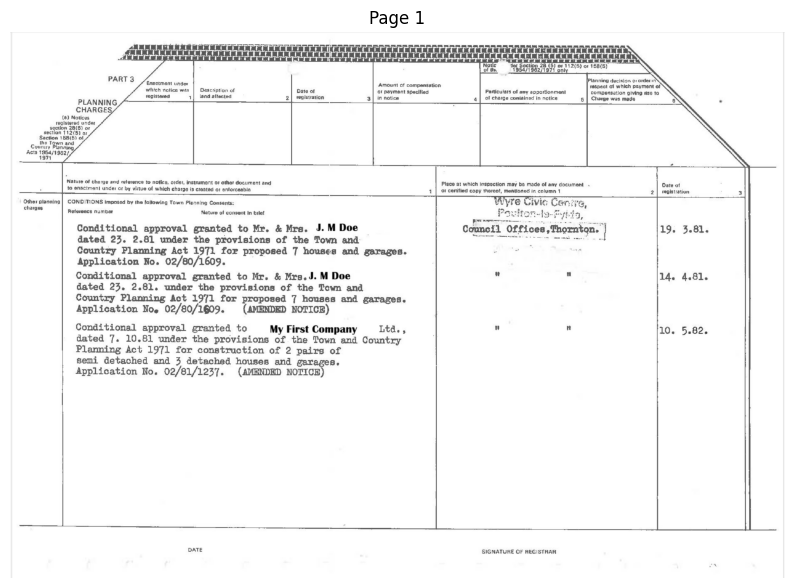

In [135]:
show_page(1)

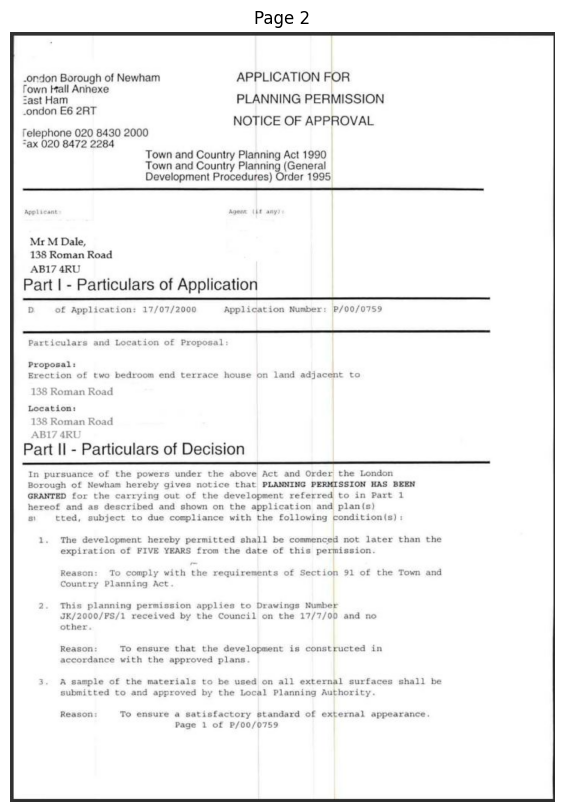

In [136]:
show_page(2)

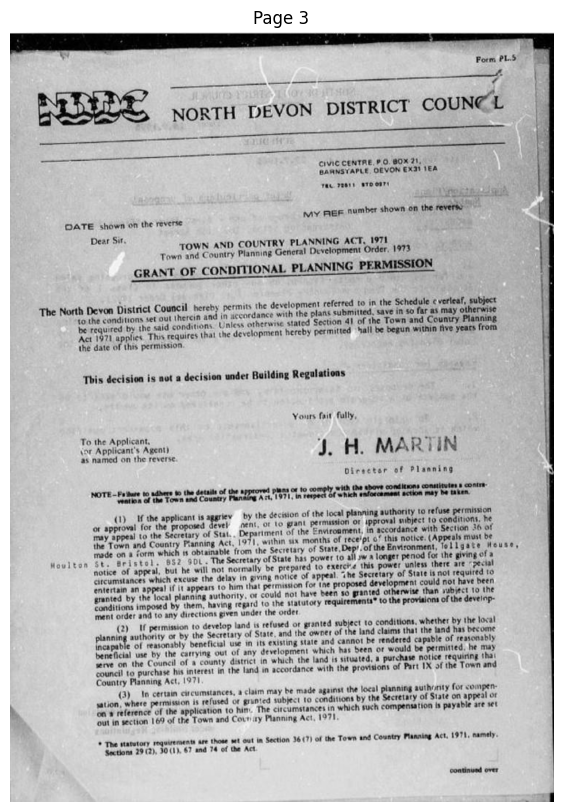

In [137]:
show_page(3)

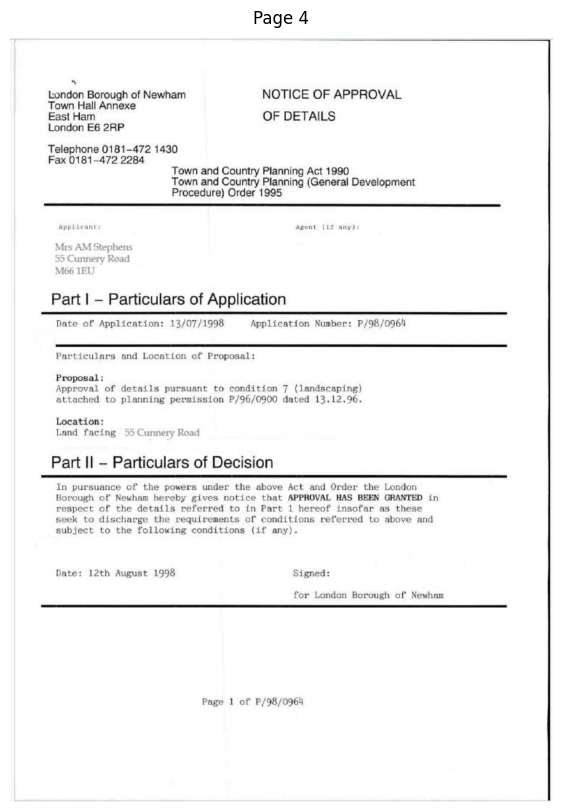

In [138]:
show_page(4)

## Section 3: Optical Character Recognition (OCR)

After converting the PDF pages into images, the next step is to extract text from those images using **Optical Character Recognition (OCR)**. The notebook uses the **Tesseract OCR engine** through the `pytesseract` Python interface to convert page images into machine-readable text.

### Why OCR is required

The planning documents are **scanned PDFs**, meaning the text is embedded in images rather than stored as selectable text. OCR is therefore necessary to make the document content accessible for automated analysis.
Once extracted, the text can be used for:

- Page classification  
- Pattern matching  
- Entity extraction  
- Structuring the document into a dataset

### OCR processing approach

Several small preprocessing steps are used to improve OCR quality:

**1. Grayscale conversion**

Images are converted to grayscale before OCR. This reduces visual noise and improves text contrast.

**2. Page-specific cropping**

The first page contains a **tabular planning register**, which can produce noisy OCR results when processed as a full page.  
To improve accuracy, the OCR step crops the relevant section of the page before extracting text.

**3. Tesseract configuration**

The OCR engine is run with the following configuration:

--oem 3
--psm 6

These settings instruct Tesseract to use the default engine and assume a **uniform block of text**, which works well for most document pages.

**4. Whitespace normalisation**

OCR output often contains irregular spacing and line breaks. After extraction, excessive whitespace is collapsed into single spaces to make the text easier to analyse.

### Output of this stage

The result of the OCR process is a **list of text strings**, where each element corresponds to the extracted text from a single page. This page-level text representation will be used in the next stage to classify page types and extract key entities such as **application numbers** and **applicant names**.

In [140]:
def ocr_image(image_path, page_number):
    """
    Extract text from an image using Tesseract OCR.

    Parameters
    ----------
    image_path : Path
        Path to the image file.
    page_number : int
        Page index used for page-specific preprocessing.

    Returns
    -------
    str
        Cleaned OCR text.
    """

    # Load image
    image = Image.open(image_path)

    # Convert to grayscale to improve OCR contrast
    image = image.convert("L")

    width, height = image.size

    # Special handling for page 1 (planning register table)
    if page_number == 1:
        # Crop lower portion where entries typically appear
        crop_start = int(height * 0.35)
        image = image.crop((0, crop_start, width, height))

    # Tesseract configuration
    config = "--oem 3 --psm 6"

    # Run OCR
    text = pytesseract.image_to_string(image, config=config)

    # Normalise whitespace
    text = " ".join(text.split())

    return text

In [141]:
texts = []

for i, img_path in enumerate(image_paths, start=1):

    print(f"\nRunning OCR on page {i}...")

    text = ocr_image(img_path, i)

    texts.append(text)

    print("Characters extracted:", len(text))
    print(text[:1500])


Running OCR on page 1...
Characters extracted: 772
Conditional approval granted to Mr. & Mra. J.M Doe © Connell Offices Thornton. | 19. 3.81. dated 23. 2.81 under the provisions of the Town and: ad Country Planning Act 1971 for proposed 7 houses and garages. = mi Application No. 02/80/1609. | Conditional approval granted to Mr. & Mrs.J. M Doe = " 14. 4.81. dated 23. 2.81. under the provisions of the Town and Country Planning Act 1971 for proposed 7 honses and garages. Application Nose 02/80/1609. (AMENDED NOTICE) | Conditional approval granted to My First Company Ltd. , | " " 10. 5.82. dated 7. 10.81 under the provisions of the Town and Country Planning Act 1971 for construction of 2 pairs of semi detached and 3 detached houses and garages. Application No. 02/81/1237. (AMENDED NOTICE) DATE SIGNATURE OF AEGISTRAR

Running OCR on page 2...
Characters extracted: 1637
ondon Borough of Newham APPLICATION FOR Town Hall Annexe =ast Ham PLANNING PERMISSION .ondon E6 2AT NOTICE OF APPROVAL Tel

## Section 4: Building the Page-Level Dataset

After extracting text from each page using OCR, the results are organised into a **structured dataset using pandas**.

Each row in the dataset represents a single page of the document and contains:

- **page** – the page number within the document  
- **image_path** – the file path of the page image  
- **text** – the OCR text extracted from that page

### Why structure the data?

Storing the OCR results in a DataFrame makes it easier to work with the document in a systematic way. In particular, it allows us to:

- analyse pages individually
- apply page classification logic
- run entity extraction functions
- inspect and debug intermediate results

### Example dataset structure

| page | image_path | text |
|-----|------------|------|
| 1 | anonymised_page_0001.png | OCR text extracted from page 1 |
| 2 | anonymised_page_0002.png | OCR text extracted from page 2 |
| 3 | anonymised_page_0003.png | OCR text extracted from page 3 |
| 4 | anonymised_page_0004.png | OCR text extracted from page 4 |

### Role in the pipeline

This page-level dataset acts as the **main structure used in the rest of the workflow**. The next steps operate on this DataFrame to:

- classify page types  
- extract application numbers  
- extract applicant names  
- generate the final structured output

In [148]:
# Ensure OCR output matches number of images

df_pages = pd.DataFrame({
    "page": range(1, len(texts) + 1),
    "image_path": image_paths,
    "text": texts
})

print(f"Total pages in dataset: {len(df_pages)}")

df_pages.head()

Total pages in dataset: 4


,page,image_path,text
0,1,/Users/ojtaiwo/Desktop/hmlr-document-analysis/...,Conditional approval granted to Mr. & Mra. J.M...
1,2,/Users/ojtaiwo/Desktop/hmlr-document-analysis/...,ondon Borough of Newham APPLICATION FOR Town H...
2,3,/Users/ojtaiwo/Desktop/hmlr-document-analysis/...,Form PL.> a NANT NORTH DEVON DISTRICT COUNGL e...
3,4,/Users/ojtaiwo/Desktop/hmlr-document-analysis/...,London Borough of Newham NOTICE OF APPROVAL To...


In [149]:
#Checking text length...
df_pages["text"].str.len()

0     772
1    1637
2    3605
3    1113
Name: text, dtype: int64

In [151]:
#Further verification to validate the key details in the text
for i, row in df_pages.iterrows():
    
    print("\nPage:", row["page"])
    
    if "Application Number" in row["text"]:
        print("Application field detected")


Page: 1

Page: 2
Application field detected

Page: 3

Page: 4
Application field detected


In [153]:
# Inspect the first few pages of OCR text
df_pages[["page", "text"]].head()

,page,text
0,1,Conditional approval granted to Mr. & Mra. J.M...
1,2,ondon Borough of Newham APPLICATION FOR Town H...
2,3,Form PL.> a NANT NORTH DEVON DISTRICT COUNGL e...
3,4,London Borough of Newham NOTICE OF APPROVAL To...


## Section 5: Page Classification

After extracting OCR text for each page, the next step is to determine **what type of document page each entry represents**.

Planning documents often contain several page formats within the same file, such as register tables, permission notices, or approval letters. Identifying the page type helps provide context for later stages of the pipeline.

### Objective

The goal of this stage is to **classify each page into a document category** based on patterns detected in the OCR text.

For the provided document, the following page types were identified:

- **Planning Register** – tabular register listing historical planning approvals  
- **Planning Permission Notice** – formal notice describing the planning decision  
- **Conditional Planning Permission** – letter granting permission subject to conditions  
- **Approval Notice** – notice confirming approval of submitted planning details

### Classification approach

Because the dataset is small and the document structure is fairly consistent, a **rule-based approach** is used instead of a machine learning model.

The classifier searches for **distinctive phrases** in the OCR text that indicate a specific page type. Examples include:

- `"conditional approval granted"` → Planning Register  
- `"planning permission"` and `"application number"` → Planning Permission Notice  
- `"conditional planning permission"` → Conditional Planning Permission  
- `"notice of approval"` → Approval Notice  

These rules were derived by inspecting the OCR output.

### Why rule-based classification

A rule-based method works well here because:

- the dataset is **small**
- page types contain **clear textual signals**
- the approach is **transparent and easy to validate**

### Output

A new column called **`page_type`** is added to the dataset.

| page | page_type |
|-----|-----------|
| 1 | Planning Register |
| 2 | Planning Permission Notice |
| 3 | Conditional Planning Permission |
| 4 | Approval Notice |

This page classification provides useful context for the next stage, where **application numbers and applicant names** are extracted.

In [154]:
# -------------------------
# 5. Page classification
# -------------------------

def classify_page(text: str) -> str:
    """
    Classify a document page based on phrases found in the OCR text.
    """

    text = text.lower()

    if "conditional approval granted" in text and "application no" in text:
        return "Planning Register"

    if "conditional planning permission" in text:
        return "Conditional Planning Permission"

    if "notice of approval" in text and "details" in text:
        return "Approval Notice"

    if "planning permission" in text and "application number" in text:
        return "Planning Permission Notice"

    return "Other"

In [155]:
df_pages["page_type"] = df_pages["text"].apply(classify_page)

df_pages[["page","page_type"]]

,page,page_type
0,1,Planning Register
1,2,Planning Permission Notice
2,3,Conditional Planning Permission
3,4,Approval Notice


## Section 6: Extracting Application Numbers

After classifying pages, the next step is to extract **planning application numbers** from the OCR text. These are key identifiers used in planning records and are required for the challenge output.

### Application number formats seen in this document

From inspecting the OCR output, application numbers appear in two main formats:

- **Register format (planning register pages)**  
  `Application No. 02/80/1609`, `Application No. 02/81/1237`

- **Notice format (planning notice pages)**  
  `Application Number: P/00/0759`, `Application Number: P/98/0964`

In both cases, the values are separated by forward slashes and may include an optional leading letter (for example `P/`).

### Avoiding false positives (dates)

Dates in the document can look very similar (for example `17/07/2000`).  
To reduce incorrect matches, extraction is **anchored to keywords** such as:

- `Application No`
- `Application Number`

This ensures we only capture numbers that appear in the expected application context.

### Handling OCR noise

OCR sometimes misreads characters, for example `P/98/o0964` where `o` should be `0`.  
A small normalisation step fixes common issues (such as `o → 0`) before storing the result.

### Output

Extracted values are stored in a new column called **`application_numbers`**. Each row contains a list of all application numbers found on that page (de-duplicated).

| page | application_numbers |
|-----:|----------------------|
| 1 | `["02/80/1609", "02/81/1237"]` |
| 2 | `["P/00/0759"]` |
| 3 | `[]` |
| 4 | `["P/98/0964"]` |

In [156]:
# Preview OCR text for each page (truncated)

for page, text in zip(df_pages["page"], df_pages["text"]):

    print("\n========================")
    print(f"PAGE {page}")
    print("========================")

    print(text[:900])


PAGE 1
Conditional approval granted to Mr. & Mra. J.M Doe © Connell Offices Thornton. | 19. 3.81. dated 23. 2.81 under the provisions of the Town and: ad Country Planning Act 1971 for proposed 7 houses and garages. = mi Application No. 02/80/1609. | Conditional approval granted to Mr. & Mrs.J. M Doe = " 14. 4.81. dated 23. 2.81. under the provisions of the Town and Country Planning Act 1971 for proposed 7 honses and garages. Application Nose 02/80/1609. (AMENDED NOTICE) | Conditional approval granted to My First Company Ltd. , | " " 10. 5.82. dated 7. 10.81 under the provisions of the Town and Country Planning Act 1971 for construction of 2 pairs of semi detached and 3 detached houses and garages. Application No. 02/81/1237. (AMENDED NOTICE) DATE SIGNATURE OF AEGISTRAR

PAGE 2
ondon Borough of Newham APPLICATION FOR Town Hall Annexe =ast Ham PLANNING PERMISSION .ondon E6 2AT NOTICE OF APPROVAL Telephone 020 8430 2000 -ax 020 8472 2264 Town and Country Planning Act 1990 Town and Countr

In [157]:
import re

# -------------------------
# Application number extraction
# -------------------------

APP_NO_PATTERN = re.compile(
    r"""
    Application\s*(?:No\.?|Nos\.?|Nose|Number)\s*[:\-]?\s*
    (
        (?:[A-Z]\s*/\s*\d{2}\s*/\s*[0-9oO]{4,5})   # e.g. P/98/o0964
        |
        (?:\d{2}\s*/\s*\d{2}\s*/\s*\d{4})          # e.g. 02/80/1609
    )
    """,
    flags=re.IGNORECASE | re.VERBOSE,
)


def _normalise_app_number(raw: str) -> str:
    """Normalise OCR quirks and whitespace in an extracted application number."""
    value = re.sub(r"\s+", "", raw)               # remove spaces
    value = value.replace("o", "0").replace("O", "0")

    parts = value.split("/")
    if len(parts) == 3 and len(parts[-1]) == 5 and parts[-1].isdigit():
        # e.g. P/98/00964 -> P/98/0964
        parts[-1] = parts[-1][-4:]
        value = "/".join(parts)

    return value


def extract_application_numbers(text: str) -> list[str]:
    """
    Extract application numbers anchored to 'Application No' / 'Application Number'
    to reduce false positives (e.g. dates).

    Supports:
    - Register format: 02/80/1609
    - Notice format:   P/00/0759
    - OCR noise:       P/98/o0964 -> P/98/0964
    """
    matches = APP_NO_PATTERN.findall(text)

    results: list[str] = []
    seen: set[str] = set()

    for match in matches:
        value = _normalise_app_number(match)
        if value not in seen:
            seen.add(value)
            results.append(value)

    return results

In [158]:
for i, row in df_pages.iterrows():
    apps = extract_application_numbers(row["text"])
    print(f"Page {row['page']} → {apps}")

Page 1 → ['02/80/1609', '02/81/1237']
Page 2 → ['P/00/0759']
Page 3 → []
Page 4 → ['P/98/0964']


## Section 7: Extracting Applicant Names

The final extraction step is to identify **applicant names** from the OCR text. Applicants may appear as either **individual people** or **companies** within the planning documents.

Examples observed in the document include:

- **Individuals:** `Mr M Dale`, `Mrs AM Stephens`, `Mr & Mrs J.M Doe`
- **Companies:** `My First Company Ltd`, `Example Holdings Limited`

### Approach

A rule-based approach using **regular expressions** is applied to detect these names in the OCR text. Two main patterns are used:

- A **person name pattern** that captures titles such as *Mr, Mrs, Miss, or Ms* followed by initials and a surname.
- A **company name pattern** that captures capitalised company names ending with *Ltd* or *Limited*.

Because OCR text can contain small recognition errors, a light **normalisation step** is applied to fix common issues (such as `Virs → Mrs`) and clean spacing or punctuation.

### Output

The extracted names are stored in a new column called **`applicants`**, where each row contains a list of applicants detected on that page.

In [159]:
import re

# -------------------------
# 7. Applicant name extraction
# -------------------------

PERSON_PATTERN = re.compile(
    r"""
    \b(?:Mr|Mrs|Miss|Ms)\.?\s*
    (?:&\s*(?:Mr|Mrs)\.?\s*)?
    (?:[A-Z]\.?\s*){1,4}
    [A-Z][A-Za-z]{1,30}\b
    """,
    flags=re.VERBOSE,
)

COMPANY_PATTERN = re.compile(
    r"\b[A-Z][A-Za-z]*(?:\s+[A-Z][A-Za-z]*){0,6}\s+(?:Ltd|Limited)\b"
)


def _normalise_ocr_text(text: str) -> str:
    """Light normalisation to reduce common OCR quirks before pattern matching."""
    text = " ".join(text.split())
    text = re.sub(r"\bVirs\b", "Mrs", text, flags=re.IGNORECASE)
    text = re.sub(r"\bMra\b", "Mrs", text, flags=re.IGNORECASE)
    return text


def _clean_applicant(candidate: str) -> str:
    """Clean up an extracted candidate string."""
    candidate = candidate.strip(" ,.|;:-")

    # Remove common leading phrase on register-style text
    candidate = re.sub(
        r"^Conditional approval granted to\s+",
        "",
        candidate,
        flags=re.IGNORECASE,
    )

    # Cut off trailing junk
    candidate = re.split(r"[©|]", candidate)[0].strip()

    # Normalise punctuation and spacing
    candidate = candidate.replace(".", "")
    candidate = re.sub(r"\s+", " ", candidate).strip()
    candidate = re.sub(r"\s*&\s*", " & ", candidate)

    # Fix missing space after titles caused by OCR (e.g. "MrsJ" -> "Mrs J")
    candidate = re.sub(r"\b(Mr|Mrs|Miss|Ms)([A-Z])\b", r"\1 \2", candidate)

    return candidate


def _dedupe_preserve_order(values: list[str]) -> list[str]:
    """De-duplicate values while preserving order (case/spacing normalised)."""
    seen: set[str] = set()
    result: list[str] = []

    for value in values:
        key = value.lower()
        key = re.sub(r"\s+", " ", key).strip()
        key = re.sub(r"\b([a-z])\s+([a-z])\b", r"\1\2", key)  # normalise initials spacing

        if key not in seen:
            seen.add(key)
            result.append(value)

    return result


def extract_applicants(text: str) -> list[str]:
    """
    Extract applicant names (people + companies) from OCR text.
    Returns a de-duplicated list of applicants found on the page.
    """
    text = _normalise_ocr_text(text)

    candidates: list[str] = []
    candidates.extend(PERSON_PATTERN.findall(text))
    candidates.extend(COMPANY_PATTERN.findall(text))

    cleaned: list[str] = []
    for c in candidates:
        c = _clean_applicant(c)

        # Avoid very short outputs (e.g. just a title)
        if len(c.split()) < 2:
            continue

        cleaned.append(c)

    return _dedupe_preserve_order(cleaned)

In [160]:
for i, row in df_pages.iterrows():
    names = extract_applicants(row["text"])
    print(f"Page {row['page']} → {names}")

Page 1 → ['Mr & Mrs JM Doe', 'My First Company Ltd']
Page 2 → ['Mr M Dale']
Page 3 → []
Page 4 → ['Mrs AM Stephens']


# Section 8. Final structured output

This section combines:
- page classification
- extracted application numbers
- extracted applicant names

into a single structured table. The output is saved for downstream use and review.

In [161]:
df_pages["application_numbers"] = df_pages["text"].apply(extract_application_numbers)
df_pages["applicants"] = df_pages["text"].apply(extract_applicants)

In [162]:
df_pages[["page", "page_type", "application_numbers", "applicants"]]

,page,page_type,application_numbers,applicants
0,1,Planning Register,"[02/80/1609, 02/81/1237]","[Mr & Mrs JM Doe, My First Company Ltd]"
1,2,Planning Permission Notice,[P/00/0759],[Mr M Dale]
2,3,Conditional Planning Permission,[],[]
3,4,Approval Notice,[P/98/0964],[Mrs AM Stephens]


In [163]:
for _, r in df_pages.iterrows():
    print("\n---")
    print("Page:", r["page"])
    print("Type:", r["page_type"])
    print("Application numbers:", r["application_numbers"])
    print("Applicants:", r["applicants"])


---
Page: 1
Type: Planning Register
Application numbers: ['02/80/1609', '02/81/1237']
Applicants: ['Mr & Mrs JM Doe', 'My First Company Ltd']

---
Page: 2
Type: Planning Permission Notice
Application numbers: ['P/00/0759']
Applicants: ['Mr M Dale']

---
Page: 3
Type: Conditional Planning Permission
Application numbers: []
Applicants: []

---
Page: 4
Type: Approval Notice
Application numbers: ['P/98/0964']
Applicants: ['Mrs AM Stephens']


In [164]:
df_out = df_pages[["page", "page_type", "application_numbers", "applicants"]].copy()

df_out["application_numbers"] = df_out["application_numbers"].apply(lambda x: "; ".join(x) if x else "")
df_out["applicants"] = df_out["applicants"].apply(lambda x: "; ".join(x) if x else "")

df_out

,page,page_type,application_numbers,applicants
0,1,Planning Register,02/80/1609; 02/81/1237,Mr & Mrs JM Doe; My First Company Ltd
1,2,Planning Permission Notice,P/00/0759,Mr M Dale
2,3,Conditional Planning Permission,,
3,4,Approval Notice,P/98/0964,Mrs AM Stephens


# Section 9. End-to-end processing pipeline

This function runs the full workflow:

1. Convert PDF pages to images
2. Perform OCR
3. Classify each page
4. Extract application numbers
5. Extract applicant names
6. Produce a structured output table

This allows the analysis to be reproduced easily on similar documents.

In [167]:
# -------------------------
# End-to-end pipeline
# -------------------------

from pathlib import Path
import pandas as pd
from pdf2image import convert_from_path


def _join_list(values: list[str]) -> str:
    """Join list values for export; return empty string for missing."""
    return "; ".join(values) if values else ""


def pdf_to_images(pdf_path: Path, output_dir: Path, dpi: int = 300) -> list[Path]:
    """Convert a PDF into PNG images (one per page) and save to output_dir."""
    output_dir.mkdir(parents=True, exist_ok=True)

    pages = convert_from_path(str(pdf_path), dpi=dpi)
    if not pages:
        return []

    stem = pdf_path.stem.replace(" ", "_")
    image_paths: list[Path] = []

    for page_num, page in enumerate(pages, start=1):
        image_path = output_dir / f"{stem}_page_{page_num:04d}.png"
        page.save(image_path, "PNG")
        image_paths.append(image_path)

    return image_paths


def process_document(pdf_path: Path, dpi: int = 300) -> pd.DataFrame:
    """
    Run the full pipeline on a single PDF:
    PDF → images → OCR → page classification → entity extraction → export table.
    """
    pdf_path = Path(pdf_path)
    print(f"Processing: {pdf_path.name}")

    # 1) PDF → images
    image_paths = pdf_to_images(pdf_path, IMAGES_DIR, dpi=dpi)
    if not image_paths:
        raise ValueError(f"No pages were rendered from: {pdf_path}")

    # 2) OCR
    texts = [ocr_image(img_path, page_num) for page_num, img_path in enumerate(image_paths, start=1)]

    # 3) Build page-level dataset
    df = pd.DataFrame({
        "page": range(1, len(texts) + 1),
        "image_path": [str(p) for p in image_paths],
        "text": texts,
    })

    # 4) Classification + extraction
    df["page_type"] = df["text"].apply(classify_page)
    df["application_numbers"] = df["text"].apply(extract_application_numbers)
    df["applicants"] = df["text"].apply(extract_applicants)

    # 5) Export-friendly view
    df_export = df[["page", "page_type", "application_numbers", "applicants"]].copy()
    df_export["application_numbers"] = df_export["application_numbers"].apply(_join_list)
    df_export["applicants"] = df_export["applicants"].apply(_join_list)

    return df_export

In [168]:
df_result = process_document(pdf_files[0])

df_result[["page","page_type","application_numbers","applicants"]]

Processing: anonymised.pdf


,page,page_type,application_numbers,applicants
0,1,Planning Register,02/80/1609; 02/81/1237,Mr & Mrs JM Doe; My First Company Ltd
1,2,Planning Permission Notice,P/00/0759,Mr M Dale
2,3,Conditional Planning Permission,,
3,4,Approval Notice,P/98/0964,Mrs AM Stephens


# Final Interpretation

The pipeline successfully processes scanned planning documents and converts them into a structured dataset containing key information from each page.

Using OCR and rule-based extraction techniques, the workflow is able to:

- Convert PDF documents into page-level images
- Extract machine-readable text using Tesseract OCR
- Organise the extracted text into a structured dataset
- Classify each page according to its document type
- Identify planning **application numbers**
- Extract **applicant names** where present

The final output is a structured table containing the page number, page type, application numbers, and applicants identified in the document. Overall, the approach demonstrates how a combination of **OCR, text processing, and rule-based extraction** can be used to transform scanned planning records into structured data suitable for further analysis.

While the rule-based approach works well for the provided document, future improvements could include:

- expanding pattern coverage for additional document layouts,
- improving OCR preprocessing for noisy scans,
- and exploring machine learning methods for more flexible page classification.

Despite these limitations, the current pipeline provides a **clear, reproducible workflow** for extracting structured information from scanned planning documents.